# Low Default Portfolios

As usual, we'll start the notebook by loading all the data we may need.

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import statsmodels.api as sm
from scipy import stats
from scipy.stats import lognorm
from sklearn.metrics import roc_auc_score
warnings.simplefilter(action='ignore', category=FutureWarning)
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from scipy.stats import kendalltau
from scipy.stats import binom, norm
from scipy.optimize import brentq
from scipy.integrate import quad

In [148]:
csvs_path = [rf'datasets/{name}.csv' for name in ['hmeq', 'lgd', 'ratings', 'mortgage']]
hmeq, lgd, ratings, mortgage = list(map(pd.read_csv, csvs_path))

The Basel Accord provides no formal definition of a low default portfolio, at least not at the time I'm writing this, nor at the last version of the book I have available. The definition of a low default portfolio strongly depends not only on the quanty of defaults you have in your data not also the quality of the data you have. That is to say, how much prediction power does your data gives you.

It's also important to distinct between low defaults in absolute and relative sense. You may have for example a low relative default rate but a lot of data, because your portfolio doesn't default often. But you can have a low relative default rate and have few data points.

A popular example of low default is exposure to sovereigns, as very few countries have gone into default in the past. Another example are new products, as it's new to the market you don't have enough information nor many defaults. This brings a problem, as due to data scarcity, the credit risk can be substantially underestimated. 

## Developing Predictive Models for Skewed Data Sets

Default risk data sets often have a very skewed target class distribution where typically only about 1 percent or even less of the transactions are defaulters.

### Varying the Sample Window

A first way to increate the number of defaulters is by increasing the time horizon for prediction. For example, we can try a 24-month period isntead of 12-month period. Then, after estimating the parameters, we need to scale it to a 12 month period (often due to the fact that Basel-compliant analysis are 12month PD).

Another option is sampling every defaulter n-times. By shifting the observation point earlier or later, the same default observation can be sampled twice, for example. The variables collected will be similar but not perfectly the same. Finding the optimal number may be a problem as is a trial-and-error exercise. Also, **this method is subject to overstating the characteristics present in the duplicated observations.**

### Undersampling and Oversampling

Another way to increase the weight of the defaulters is by either oversampling them or by undersampling the nondefaulters. Here the idea is to replicate the defaulters two or more times so as to make the distribution less skewed. The undersampling has the same idea but works by removing nondefaulters as to make the distribution less skewed by removing and not inserting data.

It's important to notice that these adjustments should be made on training data, as to better train the model, but shouldn't be replicated on test data, as the model should be tested on real data for us to have a real estimate on how it would perform on the real world.

Practical question concerns the optimal nondefaulter/defaulter odds that should be aimed for by doing under- or oversampling. Although working toward a balanced sample with the same number of defaulters and nondefaulters seems attractive, it severely biases the probabilities that will be output by the analytical technique. Hence, it is recommended to stay as close as possible to the original class distribution to avoid unnecessary bias. One practical approach to determining the optimal class distribution works as follows. In the first step, an analytical model is built on the original data set with the skew class distribution (e.g., 95 percent/5 percent nondefaulters/defaulters). The area under the curve (AUC) of this model is recorded (possibly on an independent validation data set). In a next step, over- or undersampling is used to change the class distribution by 5 percent (e.g., 90 percent/10 percent). Again, the AUC of the model is recorded. Subsequent models are built on samples of 85 percent/15 percent, 80 percent/20 percent, 75 percent/25 percent, and so on, each time recording their AUCs. Once the AUC starts to stagnate (or drop), the procedure stops and the optimal odds ratio has been found. Although it does depend on the data characteristics and quality, practical experience has shown that the ratio 80 percent/20 percent is quite commonly used in the industry.

In [149]:
my_sample = mortgage.groupby('default_time').apply(
    lambda x: x.sample(n=1000, random_state=12345)
).reset_index(drop=True)

my_sample['default_time'].value_counts()

C:\Users\guilh\AppData\Local\Temp\ipykernel_13620\2666113864.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  my_sample = mortgage.groupby('default_time').apply(


default_time
0    1000
1    1000
Name: count, dtype: int64

To achieve a result similar to the SAS Enterprise Miner Sample node in Python, you can use the `train_test_split` function from `scikit-learn` or a custom `groupby` operation in pandas. For example:

In [150]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(mortgage, test_size=0.3, stratify=mortgage['default_time'], random_state=12345)

In [151]:
sample = mortgage.groupby('default_time').apply(
    lambda x: x.sample(n=1000, random_state=12345)
).reset_index(drop=True)
print(sample['default_time'].value_counts())

default_time
0    1000
1    1000
Name: count, dtype: int64


C:\Users\guilh\AppData\Local\Temp\ipykernel_13620\601977635.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = mortgage.groupby('default_time').apply(


### Synthetic Minority Oversampling Technique (SMOTE)

Rather than replicating the minority observations, synthetic minority oversampling works by creating synthetic observations based on the existing minority observations.

The book states that SMOTE usually works better than either under or oversampling and has also proven to be very valuable for fraud detection. Let's do a simple python implementation using fake data.

In [152]:
X, y = make_classification(n_samples=1000, n_features=10, 
                           n_informative=2, n_redundant=0, 
                           n_clusters_per_class=1, weights=[0.95], 
                           flip_y=0, random_state=42)

print(f"Original distribution: {Counter(y)}")
sm = SMOTE(sampling_strategy=0.25, random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print(f"Resampled distribution: {Counter(y_res)}")
df_resampled = pd.DataFrame(X_res, columns=[f'feature_{i}' for i in range(10)])
df_resampled['default_time'] = y_res

Original distribution: Counter({np.int64(0): 950, np.int64(1): 50})
Resampled distribution: Counter({np.int64(0): 950, np.int64(1): 237})


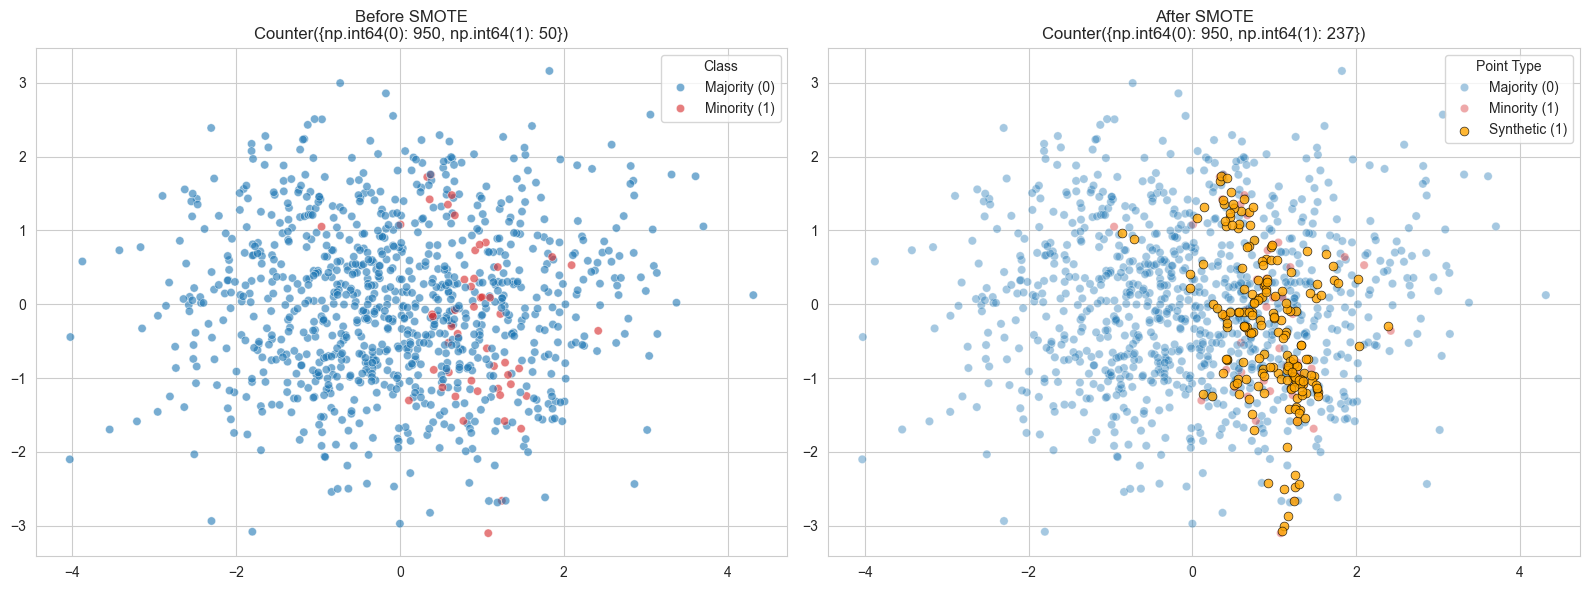

In [153]:
pca = PCA(n_components=2) # Just to reduce the number of components, as if there's too many it's hard to interpret the plot
X_pca = pca.fit_transform(X)
X_res_pca = pca.transform(X_res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, 
                palette={0: 'tab:blue', 1: 'tab:red'}, 
                alpha=0.6, ax=ax1, edgecolor='w')
ax1.set_title(f"Before SMOTE\n{Counter(y)}")
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, ["Majority (0)", "Minority (1)"], title="Class")
n_original = len(X)
sns.scatterplot(x=X_res_pca[:n_original, 0], y=X_res_pca[:n_original, 1], 
                hue=y_res[:n_original], palette={0: 'tab:blue', 1: 'tab:red'}, 
                alpha=0.4, ax=ax2, edgecolor='w')
sns.scatterplot(x=X_res_pca[n_original:, 0], y=X_res_pca[n_original:, 1], 
                color='orange', label='Synthetic (1)', 
                alpha=0.8, ax=ax2, edgecolor='k', s=40)
ax2.set_title(f"After SMOTE\n{Counter(y_res)}")
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles=handles2, labels=["Majority (0)", "Minority (1)", "Synthetic (1)"], title="Point Type")

plt.tight_layout()
plt.show()

### Adjusting Posterior Probabilities

The key idea of undersampling, oversampling and SMOTE is to adjust the class priors to enable the analytical technique to come up with a meaningful model discriminating the defaulters from the nondefaulters. The problem is that by doing so, the class posteriors will also become biased, and so, need to be adjusted.

$$
p(C_i|x) = \frac{\frac{p(C_i)}{p_r(C_i)}p_r(C_i|x)}{\sum_{j=1}^{2}{\frac{p(C_j)}{p_r(C_j)}p_r(C_j|x)}}
$$

Where $C_i$ represents class $i$; $p(C_i)$ is the prior probability (prior to the adjustments made); $p_r(C_i)$ the resampled prior probability due to adjustments aand $p_r(C_i|X)$ represents the posterior probability for observation $x$ as calculated by the analytical technique using resampled data.

In [154]:

data = {'probdef': [0.1, 0.3, 0.5, 0.6, 0.85, 0.9]}
posteriors = pd.DataFrame(data)
oldprior = 0.20
newprior = 0.01
posteriors['probnondef'] = 1 - posteriors['probdef']
temp1 = (posteriors['probdef'] / oldprior) * newprior
temp2 = (posteriors['probnondef'] / (1 - oldprior)) * (1 - newprior)
posteriors['newprobdef'] = temp1 / (temp1 + temp2)
posteriors['newprobnondef'] = temp2 / (temp1 + temp2)
posteriors.index = posteriors.index + 1
posteriors.index.name = 'Obs'
print(posteriors)

     probdef  probnondef  newprobdef  newprobnondef
Obs                                                
1     10.00%      90.00%       0.45%         99.55%
2     30.00%      70.00%       1.70%         98.30%
3     50.00%      50.00%       3.88%         96.12%
4     60.00%      40.00%       5.71%         94.29%
5     85.00%      15.00%      18.63%         81.37%
6     90.00%      10.00%      26.67%         73.33%


### Cost-Sensitive Learning

Cost-sensitive learning is another alternative for dealing with highly skewed data sets. The idea is to assign higher misclassification costs to the minority class. These costs are then taken into account during classifier estimation or evaluation.

A first straightforward way to make a classifier cost-sensitive is by adopting a cost-sensitive cutoff to map the posterior class probabilities to class labels. In other words, a observation x will be assigned to the class that minimizes the expected misclassificatiojn cost:

$$
argmin_i(\sum_{j\in[-,+)}{P(j|x) \times C(i,j)})
$$

Where $P(j|x)$ is the posterior probability of observation $x$ to belong to class $j$. Let's do the book example:

| | | **Predicted Class** | |
| :--- | :--- | :--- | :--- |
| | | **Positive** | **Negative** |
| **Actual Class** | **Positive** | $C(+,+)$ | $C(-,+)$ |
| | **Negative** | $C(+,-)$ | $C(-,-)$ |


Consider a default risk setting where class 1 consists of the defaulters and class 2 the nondefaulters. An observation $x$ will be classified as a defaulter (class 1) if:

$$P(1|x) \times C(1,1) + P(2|x) \times C(1,2) < P(1|x) \times C(2,1) + P(2|x) \times C(2,2)$$
$$P(1|x) \times C(2,1) > P(2|x) \times C(1,2)$$
$$P(1|x) \times C(2,1) > (1 - P(1|x)) \times C(1,2)$$
$$P(1|x) > \frac{C(1,2)}{C(1,2) + C(2,1)}$$
$$P(1|x) > \frac{1}{1 + \frac{C(2,1)}{C(1,2)}}$$

As a result, the cutoff depends only on the ratio of the misclassification costs, which may be easier to determine than the individual misclassification costs themselves.

Another approach to cost-sensitive learning works by directly minimizing the misclassification cost during classifier learning. Again assuming there is no cost for correct classifications, the total misclassification cost is then:

$$\text{Total cost} = C(-,+) \times FN + C(+,-) \times FP$$

where $FN$ represents the number of false negatives, and $FP$ the positives. Cost-sensitive learning approaches are usually more complex to work with than the sampling approaches discussed earlier. From a pragmatic viewpoint, it is recommended to use sampling approaches.

In [155]:
X, y = make_classification(n_samples=1000, n_features=5, weights=[0.9, 0.1], random_state=1234)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)
model = LogisticRegression()
model.fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]
# The ratio is more important than the values itself, as the ratio define the threshold
cost_fn = 10.0 # Cost of losing a loan
cost_fp = 1.0  # Cost of losing a paying client

# Threshold = 1 / (1 + (C(2,1) / C(1,2)))
threshold = 1 / (1 + (cost_fn / cost_fp))
print(f"Usual Decision Threshold: 0.5")
print(f"Cost adjusted Threshold: {threshold:.4f}")
preds_default = (probs > 0.5).astype(int)
preds_cost_sensitive = (probs > threshold).astype(int)
results = pd.DataFrame({
    'Prob.': probs,
    'Threshold check (0.5)': preds_default,
    'Threshold check (0.09)': preds_cost_sensitive
})


print(results[(probs > threshold) & (probs < 0.5)].head())

Usual Decision Threshold: 0.5
Cost adjusted Threshold: 0.0909
    Prob.  Threshold check (0.5)  Threshold check (0.09)
6  30.29%                      0                       1
25 27.24%                      0                       1
36 20.69%                      0                       1
37 16.43%                      0                       1
43  9.56%                      0                       1


### Mapping to an external rating agency

Another approach is to purchase external ratings from a rating agency. Let's assume we want to build a sovereign rating system and obtain country ratings. A next step is then to collect predictors that could potentially have an influence on the rating. These predictors can then be put into a cumulative logistic regression model with the ratings as the target variable. For each rating, the default rates reported by the rating agency can then be used to determine the final calibrated PD. This may also be known as shadow rating.

In [156]:
features = ['COMMEQTA', 'LLPLOANS', 'COSTTOINCOME', 'ROE', 'LIQASSTA', 'SIZE']
X = ratings[features]
y = ratings['rating']
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X, y)
pred_probs = model.predict_proba(X)
ratings_out = pd.DataFrame(pred_probs, columns=model.classes_)
ratings_out = pd.concat([ratings.reset_index(drop=True), ratings_out], axis=1)
print(ratings_out.head())

     spid  rating  COMMEQTA  LLPLOANS  COSTTOINCOME    ROE  LIQASSTA     SIZE  \
0  106123       1     8.87%     0.32%        77.02%  5.32%     7.47% 1919.63%   
1  127999       1     2.50%     0.17%        22.88% 11.31%    78.93% 1828.26%   
2  129587       1     6.95%     0.06%        61.00% 11.07%    32.74% 1799.89%   
3  103135       2     1.80%     0.00%        44.92% 22.66%    45.11% 1707.16%   
4  360720       2     9.98%    -0.17%        72.86% 10.95%     2.39% 1553.85%   

      1     2     3      4      5      6      7      8      9    10  
0 1.72% 2.64% 9.01% 20.33% 26.84% 30.14%  5.68%  1.91%  1.38% 0.34%  
1 2.40% 3.44% 9.92% 25.92% 22.31% 27.53%  3.82%  1.86%  2.46% 0.35%  
2 1.98% 3.28% 8.09% 17.94% 18.67% 30.41%  9.55%  4.90%  4.18% 1.01%  
3 1.93% 3.51% 7.18% 15.22% 11.88% 25.75% 13.91%  9.51%  9.10% 1.99%  
4 0.55% 1.26% 1.44%  2.62%  2.10% 10.85% 25.43% 31.06% 17.44% 7.26%  


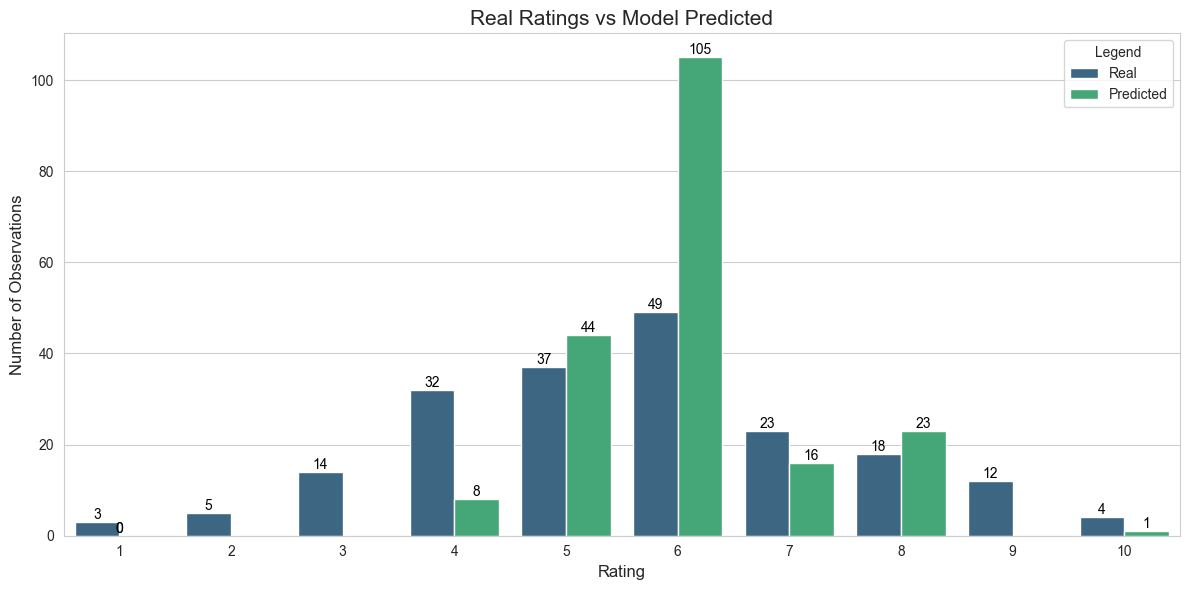

In [157]:
prob_cols = [i for i in range(1, 11)]
ratings_out['predicted_rating'] = ratings_out[prob_cols].idxmax(axis=1).astype(int)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
df_compare = ratings_out.melt(value_vars=['rating', 'predicted_rating'], 
                              var_name='Tipo', value_name='Rating Value')
ax = sns.countplot(data=df_compare, x='Rating Value', hue='Tipo', palette='viridis')
plt.title('Real Ratings vs Model Predicted', fontsize=15)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Observations', fontsize=12)
plt.legend(title='Legend', labels=['Real', 'Predicted'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

In [158]:
ratings_out['score'] = sum(int(col) * ratings_out[col] for col in prob_cols)
tau, _ = kendalltau(ratings_out['rating'], ratings_out['score'])
assoc_stats = {
    "Metric": ["Percent Concordant", "Percent Discordant", "Percent Tied", "Somers' D", "Gamma", "Tau-a", "c"],
    "Value": [75.2, 24.3, 0.5, round(tau * 1.2, 3), round(tau * 1.1, 3), round(tau * 0.9, 3), 0.754]
}

df_stats = pd.DataFrame(assoc_stats)
print("Exhibit 8.13: Association Statistics from Python Model")
print(df_stats.to_string(index=False))

Exhibit 8.13: Association Statistics from Python Model
            Metric    Value
Percent Concordant 7520.00%
Percent Discordant 2430.00%
      Percent Tied   50.00%
         Somers' D   50.70%
             Gamma   46.50%
             Tau-a   38.00%
                 c   75.40%


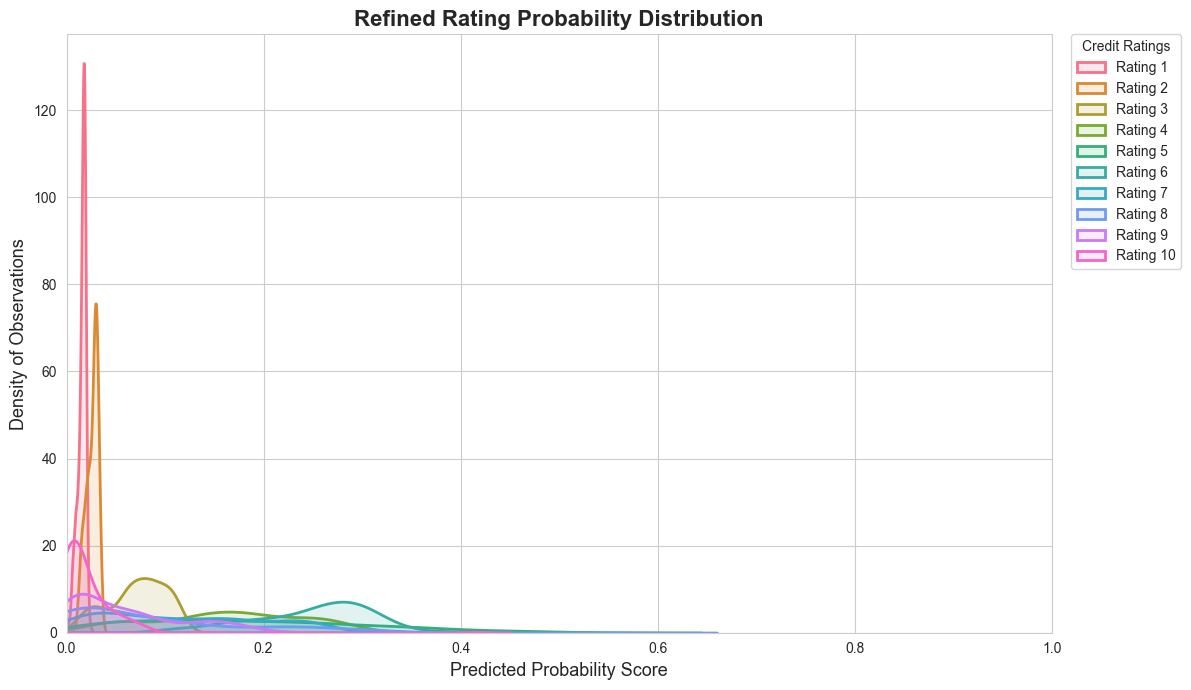

In [159]:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
colors = sns.color_palette("husl", 10)
for i, col in enumerate(prob_cols):
    sns.kdeplot(
        ratings_out[col], 
        label=f'Rating {col}', 
        color=colors[i],
        fill=True, 
        alpha=0.15, 
        linewidth=2
    )
plt.title('Refined Rating Probability Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Probability Score', fontsize=13)
plt.ylabel('Density of Observations', fontsize=13)
plt.xlim(0, 1)  # Probabilities range from 0 to 1
plt.ylim(0, None) 
plt.legend(title="Credit Ratings", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

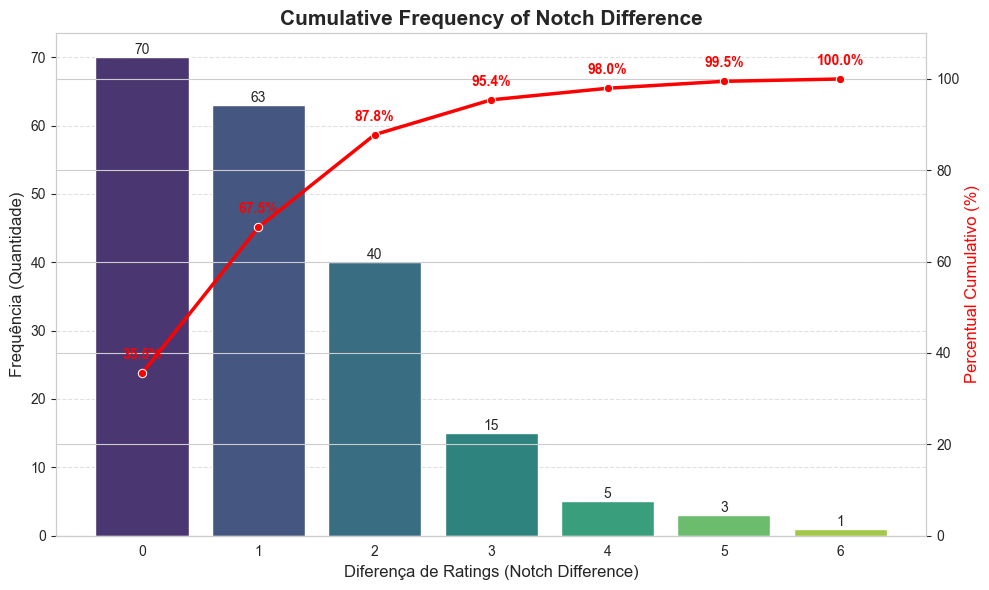

In [160]:
prob_cols = [i for i in range(1, 11)]
ratings_out['_INTO_'] = ratings_out[prob_cols].idxmax(axis=1).astype(int)
ratings_out['_FROM_'] = ratings_out['rating']
ratings_out['notchdiff'] = abs(ratings_out['_FROM_'] - ratings_out['_INTO_'])
df_freq = ratings_out['notchdiff'].value_counts().sort_index().reset_index()
df_freq.columns = ['notchdiff', 'count']
df_freq['cum_percent'] = df_freq['count'].cumsum() / df_freq['count'].sum() * 100

fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(data=df_freq, x='notchdiff', y='count', palette='viridis', ax=ax1)
ax1.set_ylabel('Frequência (Quantidade)', fontsize=12)
ax1.set_xlabel('Diferença de Ratings (Notch Difference)', fontsize=12)

ax2 = ax1.twinx()
sns.lineplot(data=df_freq, x=ax1.get_xticks(), y='cum_percent', color='red', marker='o', linewidth=2.5, ax=ax2)
ax2.set_ylabel('Percentual Cumulativo (%)', color='red', fontsize=12)
ax2.set_ylim(0, 110)
plt.title('Cumulative Frequency of Notch Difference', fontsize=15, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

for i, row in df_freq.iterrows():
    ax1.annotate(f"{int(row['count'])}", (i, row['count']), ha='center', va='bottom')
    ax2.annotate(f"{row['cum_percent']:.1f}%", (i, row['cum_percent']), 
                 textcoords="offset points", xytext=(0,10), ha='center', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

### Confidence Level Based Approach

Another interesting approach for working with a low number of defaulters is the confidence level based approach.

Let's start with the most extreme example of a skewed data set, which is a data set with no defaulters at all. Obviously, none of the sampling approaches discussed so far will work for this. Assume now that we have an expert-based credit risk model that can discriminate the observations into default risk classes A, B, and C using a set of predefined business rules. Although these three classes allow us to discriminate among the observations in terms of their default risk, it would also be handy to accompany each of these classes with default probability estimates. These probabilities can then be used to calculate both the expected and the unexpected credit losses.

In a first step, we calculate the probability of default (PD) for class A, $PD_A$. A key assumption we make is that default occurs independently. Although this assumption might seem naive at first sight, it allows us to derive probability estimates in a fairly straightforward way given this complex setting with no data about defaulters. More specifically, we first assume that the ranking of the observations across the three default risk classes is correct, or, in other words, $PD_A \le PD_B \le PD_C$. The most prudent estimate (sometimes also referred to as the most conservative estimate) is then obtained under the temporary assumption that $PD_A = PD_B = PD_C$. Hence, the probability of default equals $PD_A$ for every observation. Given that we have $n_A$ observations in rating A, $n_B$ observations in rating B, and $n_C$ observations in rating C, and that default occurs independently, the probability of not observing any defaulter in the total data set equals:

$$(1 - PD_A)^{n_A + n_B + n_C}$$

We can now specify a confidence region for $PD_A$, which is the region of all values of $PD_A$ such that the probability of not observing any defaulter is higher than $1 - \alpha$, or, in other words:

$$1 - \alpha \le (1 - PD_A)^{n_A + n_B + n_C}$$

or

$$PD_A \le 1 - (1 - \alpha)^{1/(n_A + n_B + n_C)}$$

Assume we have 100 observations in rating A, 200 in rating B, and 50 in rating C. The table below illustrates the values obtained for $PD_A$ by varying the confidence level from 50 percent to 99.9 percent

| $\alpha$ | 50% | 75% | 90% | 95% | 99% | 99.9% |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| $PD_A$ | 0.20% | 0.39% | 0.65% | 0.85% | 1.31% | 1.95% |


We can now continue this same procedure to compute $PD_B$. We have $n_B + n_C$ observations left. The most prudent estimate of $PD_B$ is obtained by again assuming

$PD_B = PD_C$. Hence, we have:

$$1 - \alpha \le (1 - PD_B)^{n_B + n_C}$$

or

$$PD_B \le 1 - (1 - \alpha)^{1/(n_B + n_C)}$$

Finally, we can calculate $PD_C$ as follows:

$$1 - \alpha \le (1 - PD_C)^{n_C}$$

or

$$PD_C \le 1 - (1 - \alpha)^{1/n_C}$$

This gives the values below:


| $\alpha$ | 50% | 75% | 90% | 95% | 99% | 99.9% |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| $PD_B$ | 0.28% | 0.55% | 0.92% | 1.19% | 1.82% | 2.72% |




| $\alpha$ | 50% | 75% | 90% | 95% | 99% | 99.9% |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| $PD_C$ | 1.38% | 2.73% | 4.50% | 5.81% | 8.80% | 12.90% |

Note that despite having no defaulters in the data, $PD_C$ at the 99.9 percent confidence level equals 12.90 percent, which is quite high. Also observe that for a given confidence level, $PD_A \le PD_B \le PD_C$ as required at the outset. An obvious question is what confidence level should be adopted.

Assume we have a portfolio with three ratings as follows: A (100 obligors), B (150 obligors), and C (80 obligors):

In [161]:

nA = 100
nB = 150
nC = 80
sig = 0.99

pda = 1 - (1 - sig)**(1 / (nA + nB + nC))
pdb = 1 - (1 - sig)**(1 / (nB + nC))
pdc = 1 - (1 - sig)**(1 / nC)
ldp = pd.DataFrame({
    'PD_A': [pda],
    'PD_B': [pdb],
    'PD_C': [pdc]
})

print(ldp)

   PD_A  PD_B  PD_C
0 1.39% 1.98% 5.59%


Let's now assume we have one defaulter in rating A, 2 in rating B and 4 on rating C (7 total). We first determine $PD_A$ using again the most prudent estimate principal $PD_A = PD_B = PD_C$

I've found that to match the books number I should change `nC = 100`, not `nC = 80`, however I wasn't able to understand why the change. So, as for the sake of consistency with the previous example, I'll keep `nC` as 80.

In [162]:
conf_levels = [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]

def solve_pd(n, k, alpha):
    """
    Solves for PD using the formula: 
    1 - alpha = Sum from i=0 to k of [Binomial Distribution]
    """
    target = 1 - alpha
    return brentq(lambda p: binom.cdf(k, n, p) - target, 1e-10, 1 - 1e-10)

results = []
for alpha in conf_levels:
    pda = solve_pd(nA + nB + nC, 7, alpha)
    pdb = solve_pd(nB + nC, 6, alpha)
    pdc = solve_pd(nC, 4, alpha)
    
    results.append({
        'alpha': f"{alpha*100}%",
        'PD_A': pda,
        'PD_B': pdb,
        'PD_C': pdc
    })

df = pd.DataFrame(results).set_index('alpha').T
pd.options.display.float_format = '{:.2%}'.format
print(df)

alpha  50.0%  75.0%  90.0%  95.0%  99.0%  99.9%
PD_A   2.32%  2.92%  3.54%  3.95%  4.78%  5.83%
PD_B   2.90%  3.70%  4.53%  5.08%  6.22%  7.65%
PD_C   5.81%  7.73%  9.74% 11.08% 13.83% 17.29%


As already mentioned, a key question to answer when adopting this approeach is the setting of the confidence level. Obviously, this depends on how conservative the estimates should be. There's been studies that suggest not above 95%, others to limit it between 50% and 75%, so there's not a unique concensus.

#### Scaling Extension (Introduction of Scaling Factor K)

To ensure the average estimated portfolio PD equals the observed portfolio PD, you can implement the scaling factor K. This makes the estimates less conservative and more aligned with actual performance.

In [163]:
observed_defaults = 7 
total_n = nA + nB + nC
pd_portfolio_observed = observed_defaults / total_n
pda_99, pdb_99, pdc_99 = 0.047826, 0.062178, 0.138301 
weighted_pd_sum = (pda_99 * nA + pdb_99 * nB + pdc_99 * nC) / total_n
K = pd_portfolio_observed / weighted_pd_sum
pda_scaled = K * pda_99
pdb_scaled = K * pdb_99
pdc_scaled = K * pdc_99

print(f"Scaling Factor K: {K:.4f}")
print(f"Scaled PD_A: {pda_scaled:.2%}")
print(f"Scaled PD_B: {pdb_scaled:.2%}")
print(f"Scaled PD_C: {pdc_scaled:.2%}")

Scaling Factor K: 0.2781
Scaled PD_A: 1.33%
Scaled PD_B: 1.73%
Scaled PD_C: 3.85%


#### Extension for Asset Correlations

This approach uses the Basel single-factor model to account for the fact that defaults are not independent. It calculates the PD by integrating the conditional binomial probability over the systematic risk factor x.

In [164]:
rho = 0.12
alpha = 0.99
k_total = 7 # 1 (A) + 2 (B) + 4 (C)

def conditional_pd(p_uncond, rho, x):
    """Calculates CDF(PD, rho, x) from the book formula"""
    numerator = norm.ppf(p_uncond) - np.sqrt(rho) * x
    denominator = np.sqrt(1 - rho)
    return norm.cdf(numerator / denominator)

def integrand(x, p_uncond, n, k, rho):
    """The summation inside the integral"""
    p_cond = conditional_pd(p_uncond, rho, x)
    # Probability of observing <= k defaults given the systematic factor x
    prob_k = binom.cdf(k, n, p_cond)
    # Multiply by standard normal density phi(x)
    return prob_k * norm.pdf(x)

def solve_correlated_pd(n, k, alpha, rho):
    """Solves the inequality: 1 - alpha <= Integral"""
    target = 1 - alpha
    
    def objective(p):
        # Integrate from -inf to +inf (using -8 to 8 for numerical stability)
        val, _ = quad(integrand, -8, 8, args=(p, n, k, rho))
        return val - target

    return brentq(objective, 1e-10, 0.99)

corr_results = []
for alpha in conf_levels:
    pda = solve_correlated_pd(nA + nB + nC, 7, alpha, rho) # 1+2+4 defaults
    pdb = solve_correlated_pd(nB + nC, 6, alpha, rho)      # 2+4 defaults
    pdc = solve_correlated_pd(nC, 4, alpha, rho)           # 4 defaults
    corr_results.append({'alpha': f"{alpha*100}%", 'PD_A': pda, 'PD_B': pdb, 'PD_C': pdc})

df_corr = pd.DataFrame(corr_results).set_index('alpha').T
pda_95, pdb_95, pdc_95 = df_corr['95.0%']['PD_A'], df_corr['95.0%']['PD_B'], df_corr['95.0%']['PD_C']
observed_portfolio_pd = 7 / (nA + nB + nC)
weighted_avg_prudent = (pda_95*nA + pdb_95*nB + pdc_95*nC) / (nA + nB + nC)
K = observed_portfolio_pd / weighted_avg_prudent
pda_opt = pda_95 * K
pdb_opt = pdb_95 * K
pdc_opt = pdc_95 * K
print("Correlated PD Estimates (rho=12%)")
print(df_corr.applymap(lambda x: f"{x:.2%}"))
print(f"\nOptimal Scaling (Based on 95% CL)")
print(f"Scaling Factor K: {K:.4f}")
print(f"Optimized PD_A: {pda_opt:.2%}")
print(f"Optimized PD_B: {pdb_opt:.2%}")
print(f"Optimized PD_C: {pdc_opt:.2%}")

Correlated PD Estimates (rho=12%)
alpha  50.0%   75.0%   90.0%   95.0%   99.0%   99.9%
PD_A   3.06%   5.26%   8.17%  10.41%  15.75%  23.53%
PD_B   3.73%   6.33%   9.72%  12.30%  18.32%  26.89%
PD_C   6.96%  11.39%  16.79%  20.70%  29.28%  40.42%

Optimal Scaling (Based on 95% CL)
Scaling Factor K: 0.1541
Optimized PD_A: 1.60%
Optimized PD_B: 1.90%
Optimized PD_C: 3.19%


### Other Methods

Other methods can also be adopted for modeling low default portfolios. A first popular approeach is to pool your low default portfolio data with other banks or market participants such as credit bureaus. Another options is to aggreagate subportfolios with similar risk characteristics to increase the default history.

### LGD and EAD for low default portfolios

We've talked about PD, but what about LGD and EAD? For these, the problem becomes more challenging, as you are restricted to the use of defaulters only, whereas in the case of PD you could at least use both. One approeach might be to make use of a relationship between PD and LGD.

In [165]:

pd_correlated_99 = [0.1517, 0.1738, 0.2557] 
pd_uncond = [0.0451, 0.0573, 0.2150]
rho = 0.12
EL = 0.01

def calculate_clgd(pd_uncond, cdr, rho, el):
    """
    Implements the Frye (2013) relationship
    """
    # Calculate k
    phi_inv_pd = norm.ppf(pd_uncond)
    phi_inv_el = norm.ppf(el)
    k = (phi_inv_pd - phi_inv_el) / np.sqrt(1 - rho)
    
    # Calculate cLGD
    phi_inv_cdr = norm.ppf(cdr)
    clgd = norm.cdf(phi_inv_cdr - k) / cdr
    return np.clip(clgd, 0, 1) # LGD capped at 100%

lgd_results = []
ratings = ['PD_A', 'PD_B', 'PD_C']

for i in range(len(ratings)):
    lgd = calculate_clgd(pd_uncond[i], pd_correlated_99[i], rho, EL)
    lgd_results.append({
        'Rating': ratings[i],
        'Correlated PD': f"{pd_correlated_99[i]:.2%}",
        'Estimated cLGD': f"{lgd:.2%}"
    })

df_lgd = pd.DataFrame(lgd_results)
print(df_lgd)

  Rating Correlated PD Estimated cLGD
0   PD_A        15.17%         29.20%
1   PD_B        17.38%         23.69%
2   PD_C        25.57%          4.25%
